# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
np.random.seed(42)
expressao_up = np.random.normal(loc=2, scale=0.5, size=500)
expressao_down = np.random.normal(loc=-2, scale=0.5, size=500)
expressao = np.concatenate([expressao_up, expressao_down])
expressao

array([ 2.24835708,  1.93086785,  2.32384427,  2.76151493,  1.88292331,
        1.88293152,  2.78960641,  2.38371736,  1.76526281,  2.27128002,
        1.76829115,  1.76713512,  2.12098114,  1.04335988,  1.13754108,
        1.71885624,  1.49358444,  2.15712367,  1.54598796,  1.29384815,
        2.73282438,  1.88711185,  2.0337641 ,  1.28762591,  1.72780864,
        2.05546129,  1.42450321,  2.18784901,  1.69968066,  1.85415313,
        1.69914669,  2.92613909,  1.99325139,  1.47114454,  2.41127246,
        1.38957818,  2.1044318 ,  1.02016494,  1.33590698,  2.09843062,
        2.36923329,  2.08568414,  1.94217586,  1.84944815,  1.260739  ,
        1.6400779 ,  1.76968061,  2.52856111,  2.17180914,  1.11847992,
        2.16204198,  1.80745886,  1.661539  ,  2.30583814,  2.51549976,
        2.46564006,  1.58039124,  1.84539381,  2.16563172,  2.48777256,
        1.76041288,  1.90717051,  1.44683251,  1.40189669,  2.40626291,
        2.67812001,  1.96399494,  2.50176645,  2.18081801,  1.67

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [2]:
import pandas as pd
np.random.seed(42)
num_genes_up = np.random.randint(100, 500, size=500)
num_genes_down = np.random.randint(100, 500, size=500)
num_genes = np.concatenate([num_genes_up, num_genes_down])
df = pd.DataFrame({"expressao": expressao, "num_genes": num_genes})
df

,expressao,num_genes
0,2.248357,202
1,1.930868,448
2,2.323844,370
3,2.761515,206
4,1.882923,171
...,...,...
995,-2.140550,326
996,-1.101157,470
997,-1.679579,114
998,-2.285589,291


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Categorizo usando decis (6 grupos iguais) baseados nos percentis da distribuição de expressão gênica:
- Grupo 1: Muito baixo (downregulated)
- Grupo 2: Baixo
- Grupo 3: Médio-baixo
- Grupo 4: Médio-alto
- Grupo 5: Alto
- Grupo 6: Muito alto (upregulated)

In [3]:
df["grupo"] = pd.qcut(df["expressao"], q=6, labels=["1", "2", "3", "4", "5", "6"])
df

,expressao,num_genes,grupo
0,2.248357,202,6
1,1.930868,448,5
2,2.323844,370,6
3,2.761515,206,6
4,1.882923,171,5
...,...,...,...
995,-2.140550,326,2
996,-1.101157,470,3
997,-1.679579,114,3
998,-2.285589,291,1


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [4]:
def tabela_frequencia(dados, n_intervalos=6):
    intervalos = pd.cut(dados, bins=n_intervalos)
    freq = intervalos.value_counts().sort_index()
    resultado = pd.DataFrame({"intervalo": freq.index, "frequencia": freq.values})
    return resultado
tabela_expressao = tabela_frequencia(df["expressao"])
tabela_expressao

,intervalo,frequencia
0,"(-3.356, -2.136]",193
1,"(-2.136, -0.924]",298
2,"(-0.924, 0.289]",9
3,"(0.289, 1.501]",76
4,"(1.501, 2.714]",381
5,"(2.714, 3.926]",43


In [5]:
tabela_num_genes = tabela_frequencia(df["num_genes"])
tabela_num_genes.head()

,intervalo,frequencia
0,"(99.601, 166.5]",165
1,"(166.5, 233.0]",156
2,"(233.0, 299.5]",176
3,"(299.5, 366.0]",176
4,"(366.0, 432.5]",150


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

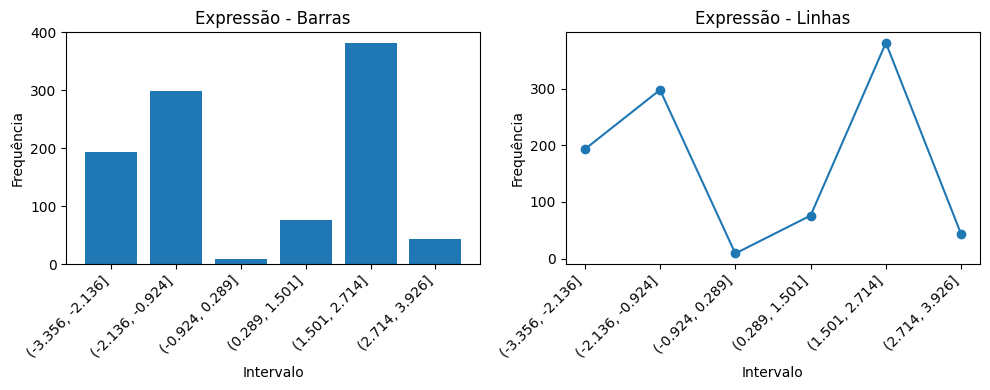

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(len(tabela_expressao)), tabela_expressao["frequencia"])
plt.title("Expressão - Barras")
plt.xlabel("Intervalo")
plt.ylabel("Frequência")
plt.xticks(range(len(tabela_expressao)), [str(x) for x in tabela_expressao["intervalo"]], rotation=45, ha="right")
plt.subplot(1, 2, 2)
plt.plot(range(len(tabela_expressao)), tabela_expressao["frequencia"], marker="o")
plt.title("Expressão - Linhas")
plt.xlabel("Intervalo")
plt.ylabel("Frequência")
plt.xticks(range(len(tabela_expressao)), [str(x) for x in tabela_expressao["intervalo"]], rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Expressão

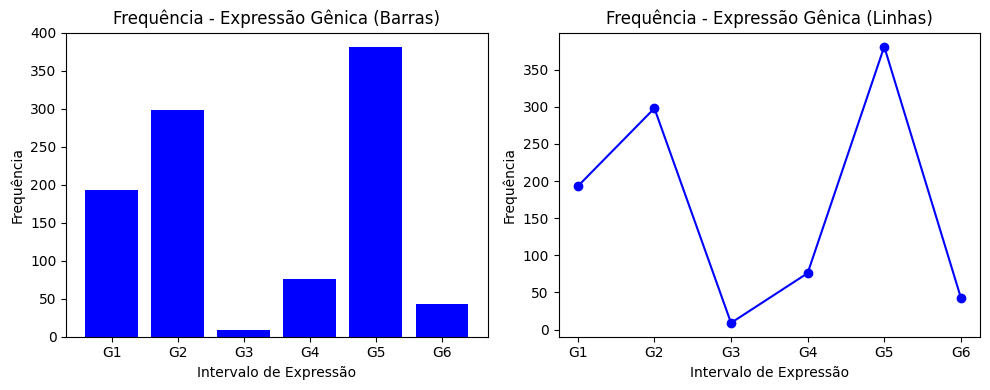

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(len(tabela_expressao)), tabela_expressao["frequencia"], color="blue")
plt.title("Frequência - Expressão Gênica (Barras)")
plt.xlabel("Intervalo de Expressão")
plt.ylabel("Frequência")
plt.xticks(range(len(tabela_expressao)), ["G"+str(i+1) for i in range(len(tabela_expressao))])
plt.subplot(1, 2, 2)
plt.plot(range(len(tabela_expressao)), tabela_expressao["frequencia"], marker="o", color="blue")
plt.title("Frequência - Expressão Gênica (Linhas)")
plt.xlabel("Intervalo de Expressão")
plt.ylabel("Frequência")
plt.xticks(range(len(tabela_expressao)), ["G"+str(i+1) for i in range(len(tabela_expressao))])
plt.tight_layout()
plt.show()

### Número

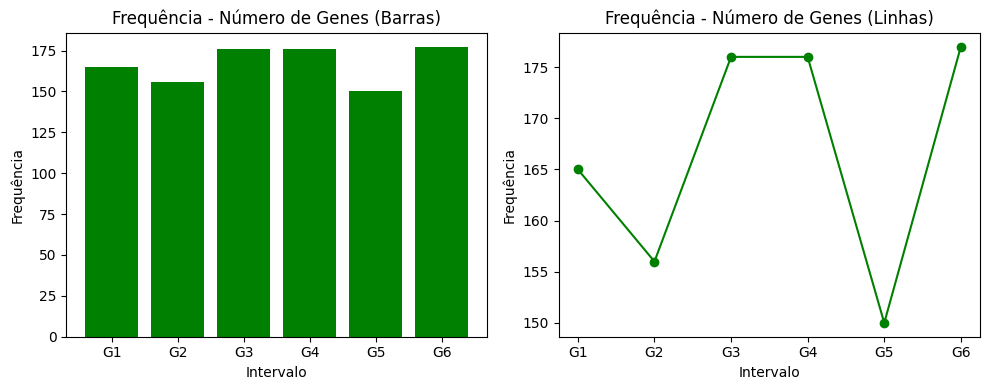

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(len(tabela_num_genes)), tabela_num_genes["frequencia"], color="green")
plt.title("Frequência - Número de Genes (Barras)")
plt.xlabel("Intervalo")
plt.ylabel("Frequência")
plt.xticks(range(len(tabela_num_genes)), ["G"+str(i+1) for i in range(len(tabela_num_genes))])
plt.subplot(1, 2, 2)
plt.plot(range(len(tabela_num_genes)), tabela_num_genes["frequencia"], marker="o", color="green")
plt.title("Frequência - Número de Genes (Linhas)")
plt.xlabel("Intervalo")
plt.ylabel("Frequência")
plt.xticks(range(len(tabela_num_genes)), ["G"+str(i+1) for i in range(len(tabela_num_genes))])
plt.tight_layout()
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

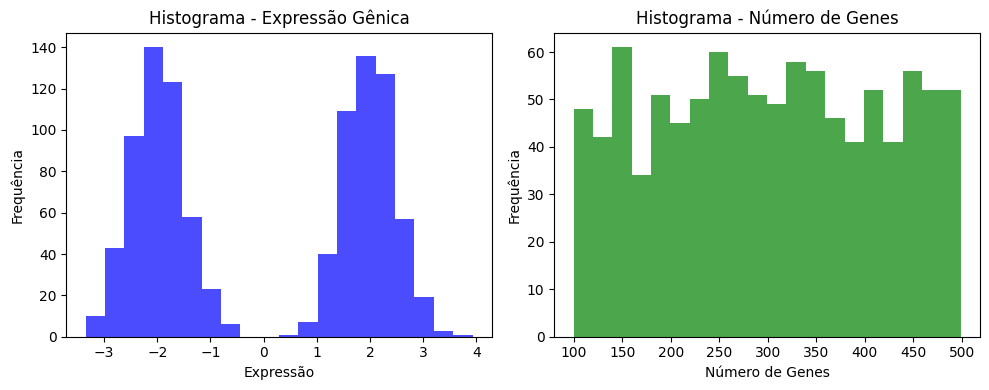

In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df["expressao"], bins=20, color="blue", alpha=0.7)
plt.title("Histograma - Expressão Gênica")
plt.xlabel("Expressão")
plt.ylabel("Frequência")
plt.subplot(1, 2, 2)
plt.hist(df["num_genes"], bins=20, color="green", alpha=0.7)
plt.title("Histograma - Número de Genes")
plt.xlabel("Número de Genes")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

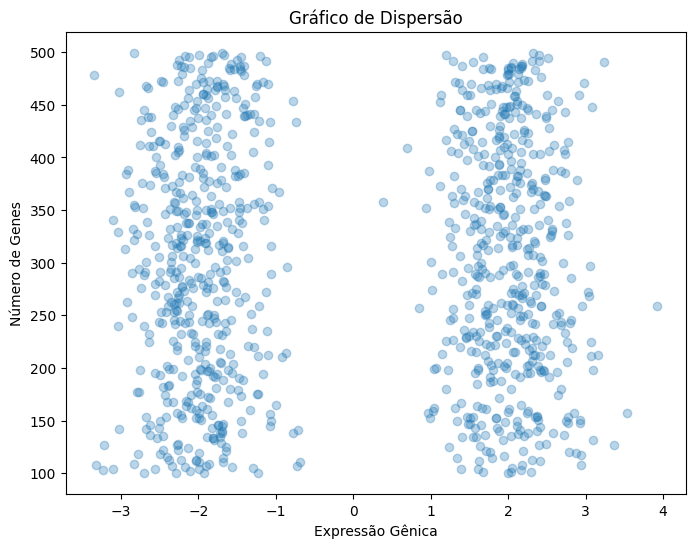

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df["expressao"], df["num_genes"], alpha=0.3)
plt.title("Gráfico de Dispersão")
plt.xlabel("Expressão Gênica")
plt.ylabel("Número de Genes")
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

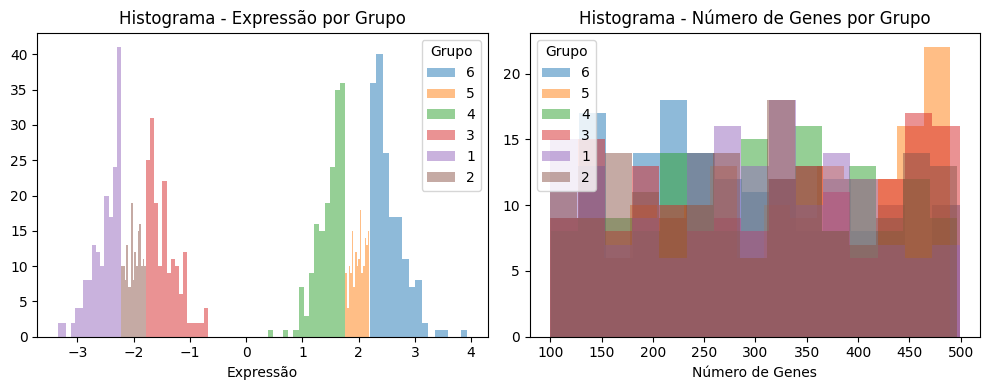

In [11]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for g in df["grupo"].unique():
    dados = df[df["grupo"] == g]["expressao"]
    plt.hist(dados, bins=15, alpha=0.5, label=g)
plt.title("Histograma - Expressão por Grupo")
plt.xlabel("Expressão")
plt.legend(title="Grupo")
plt.subplot(1, 2, 2)
for g in df["grupo"].unique():
    dados = df[df["grupo"] == g]["num_genes"]
    plt.hist(dados, bins=15, alpha=0.5, label=g)
plt.title("Histograma - Número de Genes por Grupo")
plt.xlabel("Número de Genes")
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

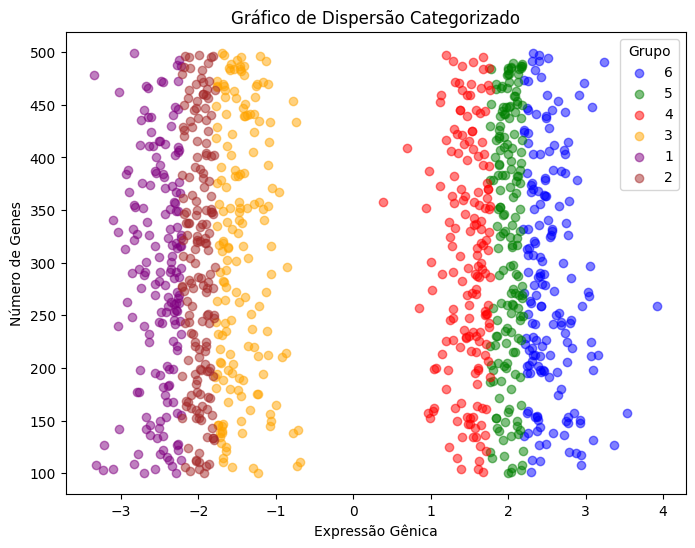

In [12]:
plt.figure(figsize=(8, 6))
cores = ["blue", "green", "red", "orange", "purple", "brown"]
for i, g in enumerate(df["grupo"].unique()):
    dados = df[df["grupo"] == g]
    plt.scatter(dados["expressao"], dados["num_genes"], alpha=0.5, label=g, color=cores[i])
plt.title("Gráfico de Dispersão Categorizado")
plt.xlabel("Expressão Gênica")
plt.ylabel("Número de Genes")
plt.legend(title="Grupo")
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Tipo |
| :--- | :---: |
| # de células positivas| Discreta |
| % de células positivas| Contínua |
| Faixa de pH| Ordinal |
| Valor de pH| Contínua |
| mol/L| Contínua |
| UFC| Discreta |
| D.O.| Contínua |
| Grupo Sanguíneo| Nominal |
| Sorologia| Nominal |